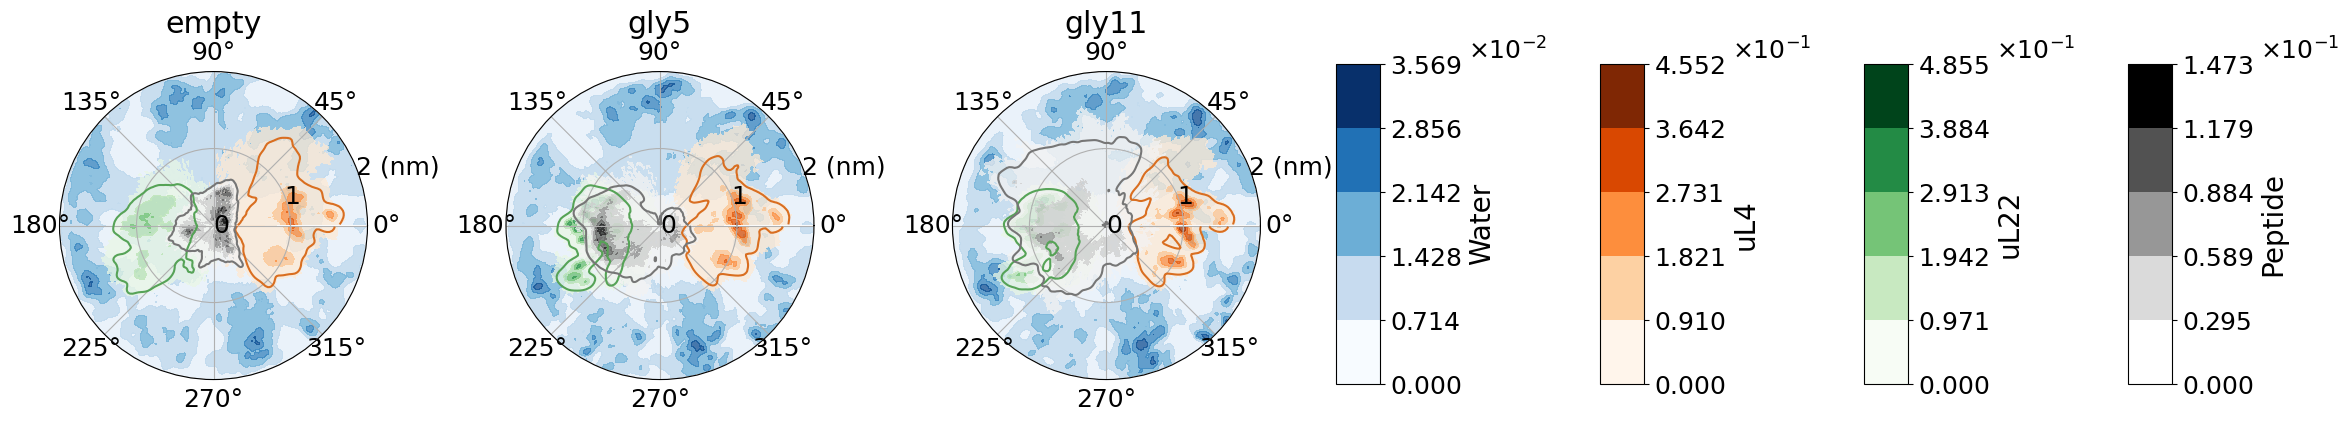

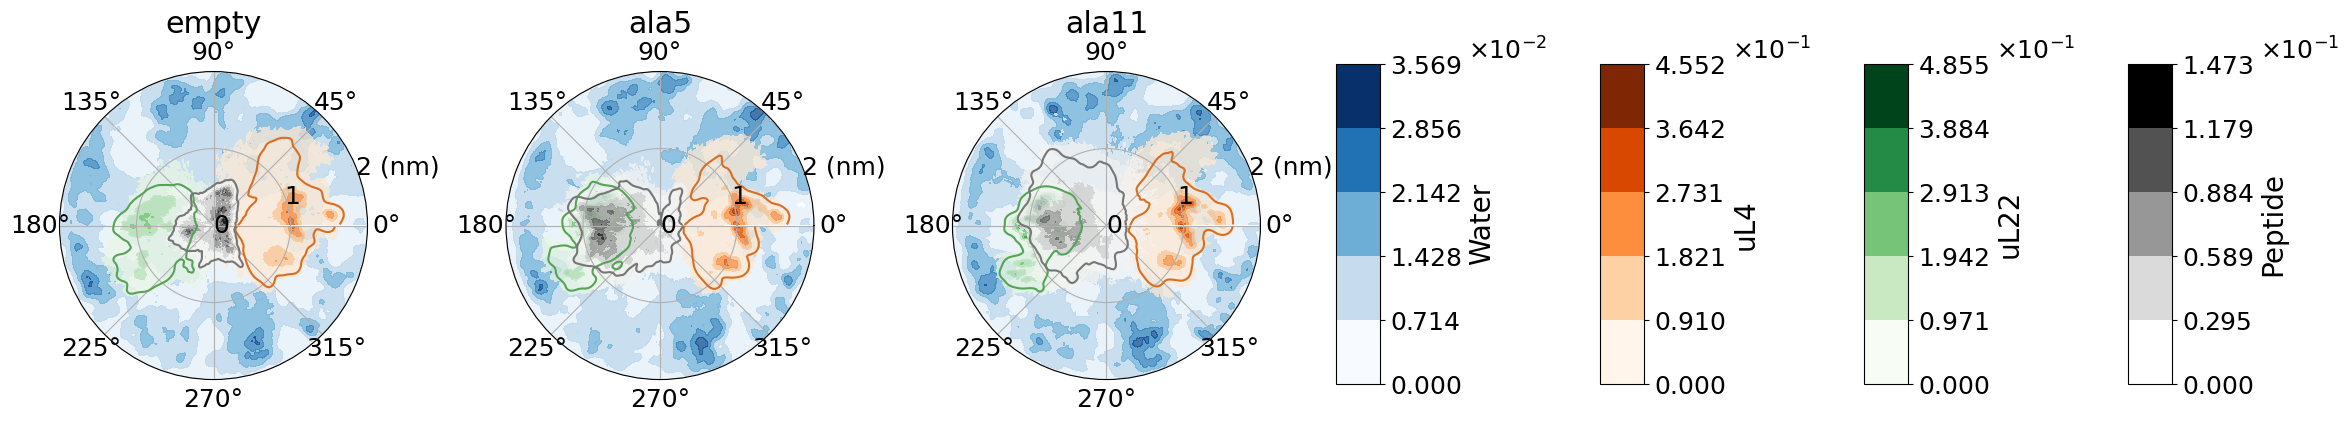

In [3]:
# this notebook takes a couple of minutes to run
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker


plt.rcParams.update({"font.size": 18})
N_TRJ = 8
RESULTS = "../output_files/polar"
SELECTION_CONFIG = {
    "water": {
        "cmap": "Blues",
        "color": "#4e8db4",
        "legend": "Water",
    },
    "uL4": {
        "cmap": "Oranges",
        "color": "#d96e20",
        "legend": "uL4",
    },
    "uL22": {
        "cmap": "Greens",
        "color": "#56a357",
        "legend": "uL22",
    },
    "peptide": {
        "cmap": "Greys",
        "color": "#767676",
        "legend": "Peptide",
    }
}
SYSTEMS = {
    "GLY": [
        "empty",
        "gly5",
        "gly11",
    ],
    "ALA": [
        "empty",
        "ala5",
        "ala11",
    ]
}
theta_edges = np.linspace(0, 2*np.pi, 360)
r_edges = np.linspace(0, 20, 60)

global_bounds = {name: {"vmin": np.inf, "vmax": -np.inf} for name in SELECTION_CONFIG}

for peptide in SYSTEMS:
    for system in SYSTEMS[peptide]:
        for selection_name in SELECTION_CONFIG:
            r_list, theta_list = [], []
            for trj_id in range(N_TRJ):
                with open(f"{RESULTS}/{system}.{trj_id}.{selection_name}.r.dat", "r") as f:
                    rs = np.array([np.fromstring(line, dtype=float, sep=" ") for line in f], dtype=object)
                with open(f"{RESULTS}/{system}.{trj_id}.{selection_name}.theta.dat", "r") as f:
                    thetas = np.array([np.fromstring(line, dtype=float, sep=" ") for line in f], dtype=object)
                for r, theta in zip(rs, thetas):
                    r_list.extend(r)
                    theta_list.extend(theta)
            theta_list = [i % (2 * np.pi) for i in theta_list]
            hist_data, _, _ = np.histogram2d(theta_list, r_list, bins=(theta_edges, r_edges), density=True)
            hist_data = ma.masked_where(hist_data == 0, hist_data)
            valid = hist_data.compressed()  # only unmasked values
            if valid.size > 0:
                global_bounds[selection_name]["vmin"] = min(global_bounds[selection_name]["vmin"], valid.min())
                global_bounds[selection_name]["vmax"] = max(global_bounds[selection_name]["vmax"], valid.max())

for p, peptide in enumerate(SYSTEMS):
    fig, axs = plt.subplots(1, len(SYSTEMS[peptide]), subplot_kw={"projection": "polar"})
    fig.set_size_inches((22, 4))
    for i, system in enumerate(SYSTEMS[peptide]):
        legend_elements = []
        for selection_name, config in SELECTION_CONFIG.items():
            r_list = []
            theta_list = []
            for trj_id in range(N_TRJ):
                with open(f"{RESULTS}/{system}.{trj_id}.{selection_name}.r.dat", "r") as f:
                    rs = np.array([np.fromstring(line, dtype=float, sep=" ") for line in f], dtype=object)
                with open(f"{RESULTS}/{system}.{trj_id}.{selection_name}.theta.dat", "r") as f:
                    thetas = np.array([np.fromstring(line, dtype=float, sep=" ") for line in f], dtype=object)
                for r, theta in zip(rs, thetas):
                    r_list.extend(r)
                    theta_list.extend(theta)
            theta_list = [i % (2 * np.pi) for i in theta_list]
            hist_data, _, _ = np.histogram2d(theta_list, r_list, bins=(theta_edges, r_edges), density=True)
            hist_data = ma.masked_where(hist_data == 0, hist_data)

            theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
            r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

            Theta, R = np.meshgrid(theta_centers, r_centers)
            levels = np.linspace(
                0,
                global_bounds[selection_name]["vmax"],
                6
            )
            cf = axs[i].contourf(
                Theta, R, hist_data.T,
                cmap=config["cmap"],
                alpha=0.75,
                levels=levels,
            )
            if selection_name != "water":
                data = hist_data.T.filled(0)
                smooth = gaussian_filter(data, sigma=1.5)
                vals = smooth.ravel()
                dr = r_edges[1] - r_edges[0]
                dtheta = theta_edges[1] - theta_edges[0]
                areas = (R * dr * dtheta).ravel()
                order = np.argsort(vals)[::-1]
                vals_sorted = vals[order]
                areas_sorted = areas[order]
                cumulative_mass = np.cumsum(vals_sorted * areas_sorted)
                cumulative_mass /= cumulative_mass[-1]
                level_percentage = 0.95
                level = vals_sorted[np.searchsorted(cumulative_mass, level_percentage)]
                axs[i].contour(
                    Theta,
                    R,
                    smooth,
                    levels=[level],
                    colors=[config["color"]],
                    linewidths=1.5,
                    zorder=20
                )

        axs[i].set_title(system, y=1.1)
        axs[i].set_rticks([0, 10, 20], labels=[])
        for r, lab in zip([0, 10, 20], [0, 1, "2 (nm)"]):
            axs[i].text(np.pi/8, r, lab, ha="left", va="center", fontsize=18, zorder=50)

    fig.subplots_adjust(right=0.7)
    for k, (selection_name, config) in enumerate(SELECTION_CONFIG.items()):
        levels = np.linspace(
            0,
            global_bounds[selection_name]["vmax"],
            6
        )
        norm = mcolors.BoundaryNorm(levels, ncolors=256)
        sm = cm.ScalarMappable(cmap=config["cmap"], norm=norm)
        sm.set_array([])
        cax = fig.add_axes([0.72 + k * 0.12, 0.1, 0.02, 0.8])
        cb = fig.colorbar(sm, cax=cax, orientation="vertical")
        cb.set_label(config["legend"], fontsize=20)

        formatter = mticker.ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((0, 0))
        cb.ax.yaxis.set_major_formatter(formatter)
        offset = cb.ax.yaxis.get_offset_text()
        offset.set_x(3)
        offset.set_ha("left")